In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

#colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]
colors = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c"]
#colors = ["#7c8ed7", "#28a4d9","#e293d0", "#bd75bc"]

# Importing the data

In [2]:
policies = pd.read_csv('tables/scotcape_policies_clean.csv')
land_decision = pd.read_csv('tables/DecisionsLandManagers.csv')
land_decision['barley']=land_decision['barley_food']+land_decision['barley_whiskey']
print(land_decision.columns)

Index(['id', 'player_id', 'player_name', 'player_role', 'round', 'sitka',
       'sitka_water', 'native', 'native_water', 'deer', 'deer_water', 'grouse',
       'grouse_water', 'cow', 'cow_water', 'sheep', 'sheep_water', 'potato',
       'potato_water', 'barley_food', 'barley_whiskey', 'barley_water',
       'fruit', 'fruit_water', 'barley'],
      dtype='object')


## Aggregating information for land use close to or not a river

In [3]:
# Remove '_water' suffix from column names that end with '_water'
no_water = [water.replace('_water', '') for water in land_decision if water.endswith('_water')]
print(no_water)
columns = list(land_decision.columns)
print(columns)

filtered_bases = [land_use for land_use in no_water if land_use in columns]
print(filtered_bases)

# Create new columns with '_total' suffix
for x in filtered_bases:
    no_water = x
    water = x+'_water'
    land_decision[x+'_total'] = land_decision[x].fillna(0) + land_decision[water].fillna(0)

print(land_decision.head())

['sitka', 'native', 'deer', 'grouse', 'cow', 'sheep', 'potato', 'barley', 'fruit']
['id', 'player_id', 'player_name', 'player_role', 'round', 'sitka', 'sitka_water', 'native', 'native_water', 'deer', 'deer_water', 'grouse', 'grouse_water', 'cow', 'cow_water', 'sheep', 'sheep_water', 'potato', 'potato_water', 'barley_food', 'barley_whiskey', 'barley_water', 'fruit', 'fruit_water', 'barley']
['sitka', 'native', 'deer', 'grouse', 'cow', 'sheep', 'potato', 'barley', 'fruit']
   id  player_id player_name player_role  round  sitka  sitka_water  native  \
0   1          1        Jack      estate      1    1.0          NaN     NaN   
1   1          2    Lindasay      estate      1    1.0          NaN     NaN   
2   1          3         Tim      farmer      1    NaN          NaN     NaN   
3   1          4         Uwe      farmer      1    NaN          NaN     NaN   
4   1          5      Rachel      farmer      1    NaN          NaN     NaN   

   native_water  deer  ...  barley  sitka_total  

# Create a column to summarize the decision making process

Here, we have four columns of interest, Researched?, interaction_score, and discussion_alignment. Researched? is binary, with 0 being no research and 1 researched. interaction_score has 4 levels, 0 is no interaction, 1 low level interaction (i.e., surveys), 2 moderate interaction through in-depth interview, and 3 is both interview and survey. Finally, discussion_alignment shows if the interaction resulted in policy, with 0 being no alignment and 1 showing that interaction happened, and policy makers delivered based on ppl's need.

I summarize here this information into a new column, decision_basis as: evidence_only (only research), goal_only (only aligned with policy makers' goals), interaction_only (only based on goal alignment), both (both evidence and interaction), intuition_only (no evidence and no interaction)

In [4]:
conditions = [
    (policies['Researched?'] == 1) & (policies['discussion_alignment']== 1),
    (policies['Researched?'] == 1),
    (policies['discussion_alignment'] == 1)
]

choice = ['both', 'evidence only', 'interaction only']

policies['decision_basis'] = np.select(conditions, choice, default='intuition only')

print(policies['decision_basis'].unique(), policies['decision_basis'].value_counts())

['intuition only' 'evidence only' 'interaction only' 'both'] decision_basis
evidence only       33
intuition only      13
interaction only     7
both                 2
Name: count, dtype: int64


# Plot count plots

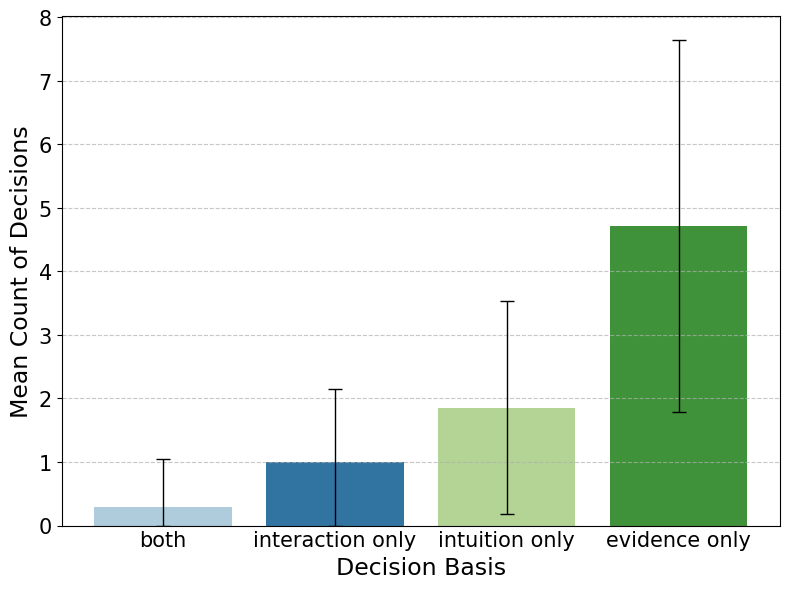

     decision_basis      mean       std
0              both  0.285714  0.755929
2  interaction only  1.000000  1.154701
3    intuition only  1.857143  1.676163
1     evidence only  4.714286  2.927700


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count the number of decisions per GameID and decision_basis
grouped = policies.groupby(['decision_basis', 'GameID']).size().reset_index(name='count')
all_combinations = pd.MultiIndex.from_product([policies['decision_basis'].unique(), policies['GameID'].unique()], names=['decision_basis', 'GameID'])
grouped = grouped.set_index(['decision_basis', 'GameID']).reindex(all_combinations, fill_value=0).reset_index()

# Calculate mean and standard deviation
mean_decisions = grouped.groupby('decision_basis')['count'].agg(['mean', 'std']).reset_index()
# mean_decisions['decision_basis'] = pd.Categorical(mean_decisions['decision_basis'],
#                                                   categories=ordered_categories,
#                                                   ordered=True)

# Sort by category order
mean_decisions = mean_decisions.sort_values('mean')
ordered_categories = mean_decisions['decision_basis'].tolist()
# Plot (vertical bars)
plt.figure(figsize=(8, 6))
sns.barplot(data=mean_decisions, x='decision_basis', y='mean', palette=colors, errorbar=None, order=ordered_categories)

# Calculate lower errors so they don’t go below 0
lower_errors = np.minimum(mean_decisions['std'], mean_decisions['mean'])   # can't subtract more than the mean
upper_errors = mean_decisions['std']                      # upper side unchanged
yerr = np.vstack([lower_errors, upper_errors])

# Add error bars manually
plt.errorbar(x=range(len(mean_decisions['mean'])),
             y=mean_decisions['mean'],
             yerr=yerr,
             fmt='none',
             c='black',
             capsize=5,
             elinewidth=1)

# Formatting
plt.xlabel('Decision Basis', fontsize=17)
plt.ylabel('Mean Count of Decisions', fontsize=17)
# plt.title('Mean Count of Decisions by Decision Basis')
# make the size of the x-axis ticks smaller
plt.tick_params(axis='x', which='both', length=0, width=0.5)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print for inspection
print(mean_decisions)


<Axes: xlabel='decision_basis', ylabel='mean'>

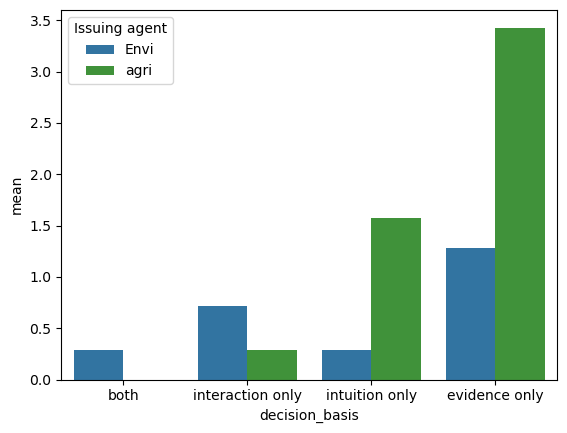

In [6]:
grouped = policies.groupby(['decision_basis', 'GameID', 'Issuing agent']).size().reset_index(name='count')
all_combinations = pd.MultiIndex.from_product([policies['decision_basis'].unique(), 
                                               policies['GameID'].unique(), 
                                               policies['Issuing agent'].unique()], 
                                               names=['decision_basis', 'GameID', 'Issuing agent'])
grouped = grouped.set_index(['decision_basis', 'GameID', 'Issuing agent']).reindex(all_combinations, fill_value=0).reset_index()
# show the mean count of decisions per decision_basis and issuing agent
mean_counts = grouped.groupby(['decision_basis', 'Issuing agent'])['count'].agg(["mean", "std"]).reset_index()
# make a barplot of the mean counts per decision_basis and issuing agent
sns.barplot(data=mean_counts, 
            x='decision_basis', 
            y='mean', 
            hue='Issuing agent', 
            order=ordered_categories, 
            palette=[colors[1], colors[3]],
)

In [7]:
# Fix naming to save space
ordered_categories = [x.replace(" only", "") for x in ordered_categories]
mean_decisions["decision_basis"] = mean_decisions["decision_basis"].apply(
    lambda x: x.replace(" only", "")
)
mean_counts["decision_basis"] = mean_counts["decision_basis"].apply(
    lambda x: x.replace(" only", "")
)
mean_counts["Issuing agent"] = mean_counts["Issuing agent"].replace(
    {"Envi": 'Env.', "agri": 'Agr.'}
)

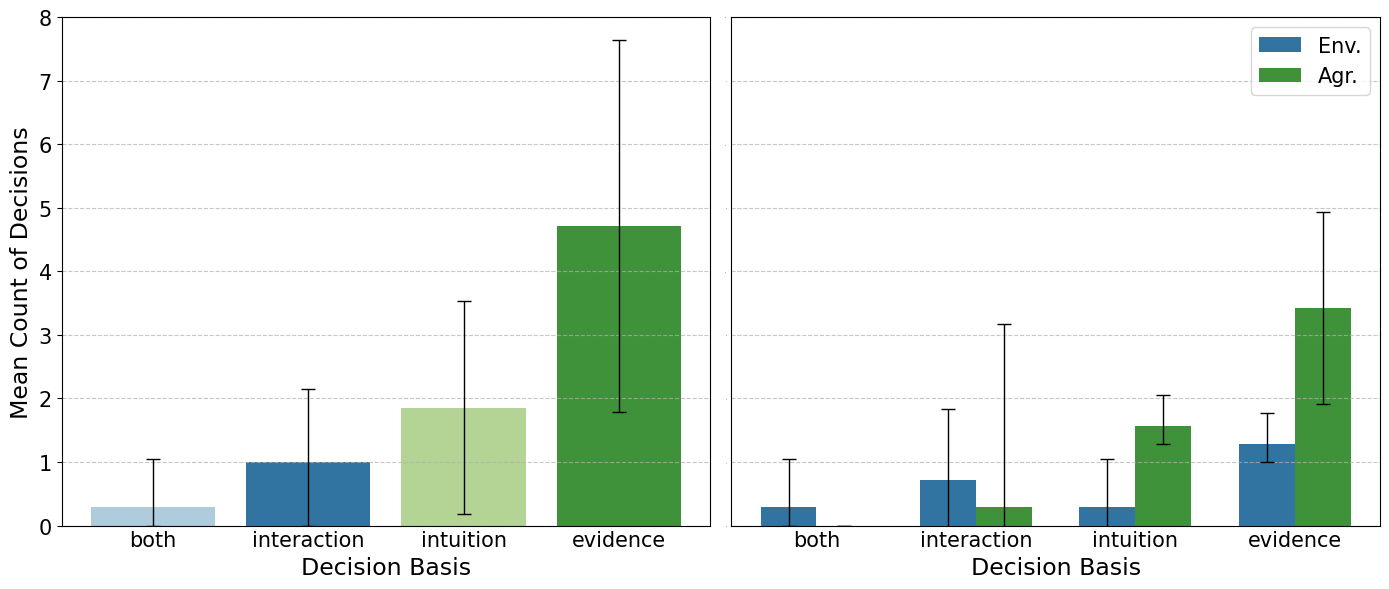

In [8]:
# Combined plot for the paper
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
sns.barplot(data=mean_decisions, 
            x='decision_basis',
            y='mean', 
            palette=colors, 
            errorbar=None, 
            order=ordered_categories,
            ax=axes[0]   
)
# Calculate lower errors so they don’t go below 0
lower_errors = np.minimum(mean_decisions['std'], mean_decisions['mean'])   # can't subtract more than the mean
upper_errors = mean_decisions['std']                      # upper side unchanged
yerr = np.vstack([lower_errors, upper_errors])
axes[0].errorbar(
    x=range(len(mean_decisions['mean'])),
    y=mean_decisions['mean'],
    yerr=yerr,
    fmt='none',
    c='black',
    capsize=5,
    elinewidth=1
)

axes[0].set_xlabel('Decision Basis', fontsize=17)
axes[0].set_ylabel('Mean Count of Decisions', fontsize=17)
axes[0].tick_params(axis='x', which='both', length=0, width=0.5)
axes[0].tick_params(axis='both', labelsize=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

bar_width = 0.7
sns.barplot(data=mean_counts, 
            x='decision_basis', 
            y='mean', 
            hue='Issuing agent', 
            order=ordered_categories, 
            palette=[colors[1], colors[3]],
            ax=axes[1],
            width=bar_width)
# Calculate lower errors so they don’t go below 0
lower_errors = np.minimum(mean_counts['std'], mean_counts['mean'])   # can't subtract more than the mean
upper_errors = mean_counts['std']                      # upper side unchanged
yerr = np.vstack([lower_errors, upper_errors])
# reorder the data to match the order of the bars
mean_counts = mean_counts.sort_values(by='decision_basis', key=lambda x: x.map({cat: i for i, cat in enumerate(ordered_categories)}))

# Positions of the errorbars
off_set = bar_width/4
x = [i+off_set for i in range(len(ordered_categories))]+[i-off_set for i in range(len(ordered_categories))]
x= np.sort(x)

# adding the error bars
axes[1].errorbar(
    x=x,
    y=mean_counts['mean'],
    yerr=yerr,
    fmt='none',
    c='black',
    capsize=5,
    elinewidth=1
)

axes[1].set_xlabel('Decision Basis', fontsize=17)
axes[1].set_ylabel('', fontsize=17)
axes[1].tick_params(axis='both', which='both', length=0, width=0.5)
axes[1].tick_params(axis='x', labelsize=15)
axes[1].tick_params(axis='y', labelsize=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, 8)
axes[1].set_ylim(0, 8)
axes[1].legend(fontsize=15)


plt.tight_layout()
plt.show()

In [9]:
policy_long = policies.melt(id_vars=['GameID', 'Round', 'Issuing agent', 'target_group', 'policy type', 'decision_basis'],
                            value_vars=['target_land_use_1', 'target_land_use_2', 'target_land_use_3', 'target_land_use_4'],
                            var_name='target_slot',
                            value_name='target_land_use')

policy_long = policy_long.dropna(subset='target_land_use')
policy_long['target_land_use'] = policy_long['target_land_use'].str.strip().str.lower()
policy_long['effect_round'] = policy_long['Round'] + 1

land_decision_long = land_decision.melt(id_vars=['id', 'player_id', 'player_role', 'round'],
                                        value_vars=[land_use for land_use in land_decision if land_use.endswith('_total')],
                                        var_name='land use',
                                        value_name='number of tiles')

In [10]:
expanded_policies = []  # This will store new rows
# Iterate over each row (policy) in the original DataFrame
for _, row in policy_long.iterrows():
    # Create a new row for each subsequent round AFTER the policy was made
    for r in range(row['Round'] + 1, 5):  # round+1 to 4 inclusive
        expanded_policies.append(row.to_dict() | {'effect_round': r})
policy_long_expanded = pd.DataFrame(expanded_policies)

# Merge policies and land use decision dataframes

In [11]:
land_use_summary = land_decision_long.groupby(
    ['id', 'round', 'player_id', 'player_role', 'land use']
)['number of tiles'].sum().reset_index()

rename_land = {
    'native':'native woodland',
    'barley_food':'barley',
    'barley_whiskey':'barley',
    'cow':'cattle',
    'fruit':'fruit tree'
    
}

rename_policy = {
    'fruit':'fruit tree',
    'cow':'cattle',
}

land_use_summary['land use'] = land_use_summary['land use'].str.replace('_total$', '', regex=True)
land_use_summary['land use'] = land_use_summary['land use'].replace(rename_land)
policy_long_expanded['target_land_use'] = policy_long_expanded['target_land_use'].replace(rename_policy)

print(land_use_summary)

land_policy = policy_long_expanded.merge(
    land_use_summary,
    left_on=['GameID', 'target_land_use', 'target_group'],
    right_on=['id', 'land use', 'player_role'],
    how='left'
)

land_policy['after_policy']=land_policy['round']>=land_policy['effect_round']

land_policy['number of tiles'] = land_policy['number of tiles'].fillna(0)

print(land_policy)

      id  round  player_id player_role         land use  number of tiles
0      1      1          1      estate           barley              0.0
1      1      1          1      estate           cattle              0.0
2      1      1          1      estate             deer              2.0
3      1      1          1      estate       fruit tree              0.0
4      1      1          1      estate           grouse              0.0
...   ..    ...        ...         ...              ...              ...
1417   7      4         41      farmer           grouse              0.0
1418   7      4         41      farmer  native woodland              4.0
1419   7      4         41      farmer           potato              4.0
1420   7      4         41      farmer            sheep              0.0
1421   7      4         41      farmer            sitka              0.0

[1422 rows x 6 columns]
      GameID  Round Issuing agent target_group policy type  decision_basis  \
0          1      1  

In [12]:
print(land_use_summary['land use'].value_counts())
print(policy_long_expanded['target_land_use'].value_counts())

land use
barley             158
cattle             158
deer               158
fruit tree         158
grouse             158
native woodland    158
potato             158
sheep              158
sitka              158
Name: count, dtype: int64
target_land_use
native woodland    26
cattle             19
fruit tree         17
potato             16
sheep              12
barley             10
deer                5
housing             4
grouse              2
Name: count, dtype: int64


In [13]:
# Create a list of all target land use columns
target_columns = ['target_land_use']

# This will return True if the land use type is in any of the target columns
land_policy['land_use_match'] = land_policy.apply(
    lambda row: any(row['land use'] == row[col] for col in target_columns),
    axis=1
)
land_policy.to_csv('tables/land_use_policy.csv')

<Axes: xlabel='target_land_use', ylabel='count'>

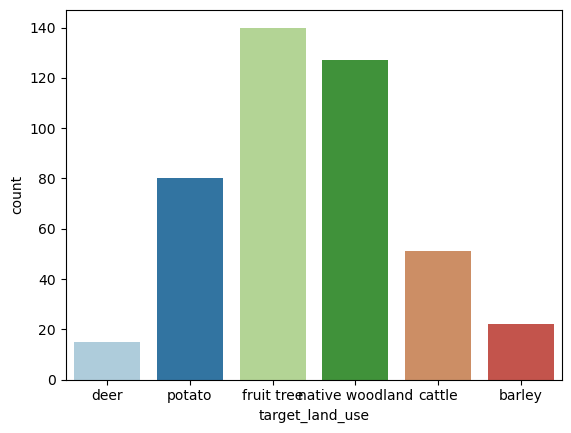

In [14]:
sns.countplot(x='target_land_use', data=land_policy[land_policy['number of tiles']!=0], palette=colors+["#dd8b54", "#d74338", ])

# Link policy decision making with land use

We evaluate the proportion of players who adopted a new policy and correlate it with the decision making process for the policy. We also compute the significance of the difference in the number of tiles before and after the policy implementation.

In [15]:
land_policy['after_policy_clean'] = land_policy['after_policy'].astype(str).str.strip().str.lower()

# Apply conditional logic
land_policy.loc[land_policy['after_policy_clean'] == 'false', 'before'] = land_policy['number of tiles']
land_policy.loc[land_policy['after_policy_clean'] == 'true', 'after'] = land_policy['number of tiles']

mean_before = land_policy.groupby(['decision_basis', 'land use'])['before'].mean()
mean_after = land_policy.groupby(['decision_basis', 'land use'])['after'].mean()

mean_effectiviness = mean_after-mean_before

mean_effectiviness = mean_effectiviness.reset_index()
mean_effectiviness.columns = ['decision_basis', 'land use', 'effectiveness']

In [16]:
from scipy.stats import mannwhitneyu

In [17]:
results = []

for decision in land_policy['decision_basis'].dropna().unique():
    for land_use in land_policy['land use'].dropna().unique():
        for policy_type in land_policy['policy type'].dropna().unique():
            for target_group in land_policy['target_group'].dropna().unique():

                subset = land_policy[
                    (land_policy['decision_basis'] == decision) &
                    (land_policy['land use'] == land_use) &
                    (land_policy['policy type'] == policy_type) &
                    (land_policy['target_group'] == target_group)
                ]

                before = subset[subset['after_policy'] == False]['number of tiles']
                after = subset[subset['after_policy'] == True]['number of tiles']

                if len(before) > 1 and len(after) > 1:
                    stat, p = mannwhitneyu(after, before, alternative='two-sided')
                    n1 = len(after)
                    n2 = len(before)
                    rbc = 1 - (2 * stat) / (n1 * n2)

                    results.append({
                        'decision_basis': decision,
                        'land_use_type': land_use,
                        'policy_type': policy_type,
                        'target_group': target_group,
                        'mean_before': before.mean(),
                        'mean_after': after.mean(),
                        'u_statistic': stat,
                        'p_value': p,
                        'rank_biserial_corr': rbc
                    })

results_df = pd.DataFrame(results).sort_values('p_value')

def significance_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

results_df['significance'] = results_df['p_value'].apply(significance_marker)

## Dumbbell plot with rank-biserial correlation

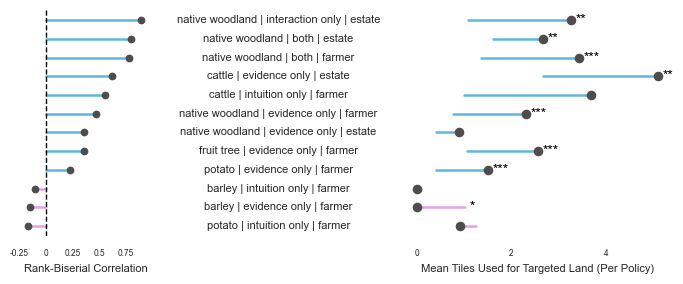

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
# Prepare data
colors = ["#7c8ed7", "#60b6db","#e293d0", "#e5a2e4"]
dumbbell_df = results_df.sort_values(
    by=["land_use_type", "decision_basis", "target_group", "policy_type"]
).copy()
dumbbell_df["label"] = (
    dumbbell_df["land_use_type"] + " | " + 
    dumbbell_df["decision_basis"] + " | " +
    dumbbell_df["target_group"]) 

# CONFIGURATION
label_fontsize = 8
dot_size = 35
lw_stick = 1.8

# Filter & preprocess
dumbbell_df['delta'] = dumbbell_df['mean_after'] - dumbbell_df['mean_before']
dumbbell_df = dumbbell_df[dumbbell_df['delta'] != 0]
dumbbell_df = dumbbell_df[~dumbbell_df['policy_type'].str.contains("tax", case=False, na=False)]
dumbbell_df['max'] = dumbbell_df[['mean_before', 'mean_after']].max(axis=1)

# Keep order from dumbbell plot
dumbbell_df = dumbbell_df.sort_values("rank_biserial_corr", ascending=False).copy()
dumbbell_df.reset_index(drop=True, inplace=True)

# Style
sns.set_theme(style="white")  # Minimal background, no grid

# Figure with 3 subplots
size_multipier = 0.5
fig,  ax = plt.subplots(
    ncols=3, 
    sharey=True, 
    figsize=(14*size_multipier, len(dumbbell_df) * 0.5*size_multipier),
    gridspec_kw={'width_ratios': [1, 1,2]}
)
(ax2, labels, ax1) = ax
# Colors
pos_change = colors[1]
neg_change = colors[3]
point_color = "#4d4d4d"


labels.axis('off')  # hide the middle axis
# Custom axis for the text of the labels
for i, row in dumbbell_df.iterrows():
    y = i
    labels.text(0.5, y, row["label"], va='center', ha='center', fontsize=label_fontsize)


# ---- Dumbbell Plot ----
for i, row in dumbbell_df.iterrows():
    y = i
    ax1.plot(
        [row["mean_before"], row["mean_after"]], [y, y],
        color=pos_change if row['delta'] > 0 else neg_change, lw=lw_stick, zorder=1
    )
    # ax1.scatter(row["mean_before"], y, s=dot_size, color=point_color, zorder=2)
    after_dot_color = point_color
    ax1.scatter(row["mean_after"], y, s=dot_size, color=after_dot_color, zorder=3)

    if row["p_value"] < 0.05:
        ax1.text(row["max"] + 0.1, y, row["significance"],
                 va='center', ha='left', fontsize=label_fontsize+2, color='black')

ax1.set_xlabel("Mean Tiles Used for Targeted Land (Per Policy)", fontsize=label_fontsize)
ax1.set_xticks(ticks=[0,2,4], labels=[0,2,4], fontsize=label_fontsize-2)
sns.despine(ax=ax1, right=True, left=True, bottom=True)

# ---- Lollipop Plot ----
# Map correlation to y positions from dumbbell_df ordering
for i, row in dumbbell_df.iterrows():
    ax2.plot([0, -row["rank_biserial_corr"]], [i, i], color=neg_change if row["rank_biserial_corr"]>0 else pos_change, lw=lw_stick)
    ax2.scatter(-row["rank_biserial_corr"], i, s=dot_size*0.6, color=point_color, zorder=3)

ax2.axvline(0, color="black", linestyle="--", lw=1)
ax2.set_xlabel("Rank-Biserial Correlation", fontsize=label_fontsize)
ax2.set_yticks(range(len(dumbbell_df)))
ax2.set_yticklabels([])  
ax2.set_xlim(-0.25, 1)
ax2.set_xticks(ticks=[-0.25,0,0.25,0.50, 0.75], labels=[-0.25,0,0.25,0.50, 0.75], fontsize=label_fontsize-2)


sns.despine(ax=ax2, left=True, bottom=True)

plt.tight_layout()
plt.savefig("dumbbell_lollipop_side_by_side.png", format='png', dpi=500)
plt.show()
